<a href="https://colab.research.google.com/github/yassinemaataoui/Colab_project/blob/main/AFC1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install prince

In [ ]:
# ===============================
# 1. Import des bibliothèques
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import prince

In [ ]:
# ===============================
# 2. Création du tableau de contingence
# ===============================
data = {
    "Cheveux": [
        "Noir","Noir","Noir","Noir",
        "Brun","Brun","Brun","Brun",
        "Roux","Roux","Roux","Roux",
        "Blond","Blond","Blond","Blond"
    ],
    "Yeux": ["Brun","Bleu","Noisette","Vert"] * 4,
    "Effectif": [
        68, 20, 15, 5,
        119, 84, 54, 29,
        26, 17, 14, 14,
        7, 94, 10, 16
    ]
}

df = pd.DataFrame(data)
data

{'Cheveux': ['Noir',
  'Noir',
  'Noir',
  'Noir',
  'Brun',
  'Brun',
  'Brun',
  'Brun',
  'Roux',
  'Roux',
  'Roux',
  'Roux',
  'Blond',
  'Blond',
  'Blond',
  'Blond'],
 'Yeux': ['Brun',
  'Bleu',
  'Noisette',
  'Vert',
  'Brun',
  'Bleu',
  'Noisette',
  'Vert',
  'Brun',
  'Bleu',
  'Noisette',
  'Vert',
  'Brun',
  'Bleu',
  'Noisette',
  'Vert'],
 'Effectif': [68, 20, 15, 5, 119, 84, 54, 29, 26, 17, 14, 14, 7, 94, 10, 16]}

In [ ]:
# Tableau de contingence
table = pd.pivot_table(
    df,
    values="Effectif",
    index="Cheveux",
    columns="Yeux",
    aggfunc="sum"
)

print("Tableau de contingence :")
print(table)

Tableau de contingence :
Yeux     Bleu  Brun  Noisette  Vert
Cheveux                            
Blond      94     7        10    16
Brun       84   119        54    29
Noir       20    68        15     5
Roux       17    26        14    14


In [ ]:
# ===============================
# 3. Réalisation de l’AFC
# ===============================
ca = prince.CA(
    n_components=2,
    n_iter=10,
    copy=True,
    random_state=42
)

ca = ca.fit(table)

In [ ]:
# Coordonnées factorielles
row_coords = ca.row_coordinates(table)
col_coords = ca.column_coordinates(table)

print("\nCoordonnées des lignes (Cheveux) :")
print(row_coords)

print("\nCoordonnées des colonnes (Yeux) :")
print(col_coords)


Coordonnées des lignes (Cheveux) :
                0         1
Cheveux                    
Blond    0.835348 -0.069579
Brun    -0.148253  0.032666
Noir    -0.504562 -0.214820
Roux    -0.129523  0.319642

Coordonnées des colonnes (Yeux) :
                 0         1
Yeux                        
Bleu      0.547414 -0.082954
Brun     -0.492158 -0.088322
Noisette -0.212597  0.167391
Vert      0.161753  0.339040


In [ ]:
# Valeurs propres
eigenvalues = ca.eigenvalues_
print("\nValeurs propres :", eigenvalues)


Valeurs propres : [0.20877265 0.02222661]


In [ ]:
# Pourcentage d’inertie
inertia = eigenvalues / sum(eigenvalues) * 100
print("\nInertie expliquée :")
print("Dim 1 :", inertia[0], "%")
print("Dim 2 :", inertia[1], "%")


Inertie expliquée :
Dim 1 : 90.37805836477716 %
Dim 2 : 9.621941635222841 %


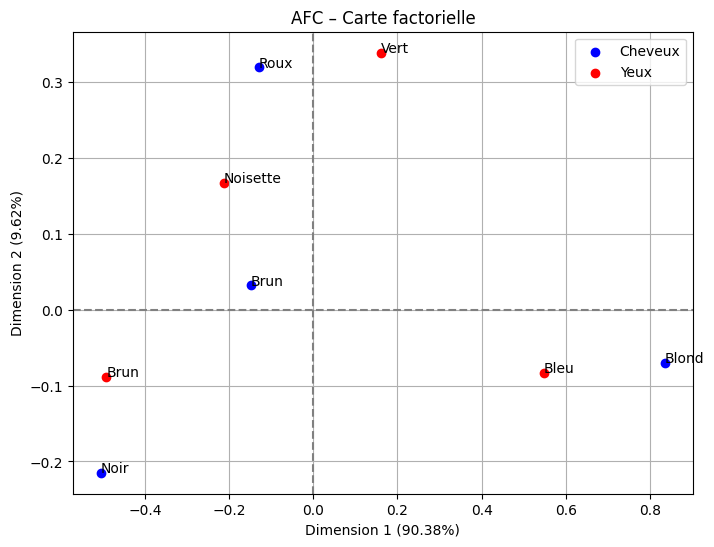

In [ ]:
# ===============================
# 4. Visualisation – Carte factorielle
# ===============================
plt.figure(figsize=(8,6))

plt.scatter(row_coords[0], row_coords[1], color="blue", label="Cheveux")
plt.scatter(col_coords[0], col_coords[1], color="red", label="Yeux")

for i in row_coords.index:
    plt.text(row_coords.loc[i,0], row_coords.loc[i,1], i)

for i in col_coords.index:
    plt.text(col_coords.loc[i,0], col_coords.loc[i,1], i)

plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

plt.xlabel(f"Dimension 1 ({inertia[0]:.2f}%)")
plt.ylabel(f"Dimension 2 ({inertia[1]:.2f}%)")
plt.title("AFC – Carte factorielle")
plt.legend()
plt.grid()
plt.show()